In [24]:
import pandas as pd
import numpy as np
import re
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer
# from vadersentiment.vadersentiment import SentimentIntensityAnalyzer
import transformers
from transformers import pipeline

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\khare\AppData\Roaming\nltk_data...


In [26]:
data = pd.read_csv('book_reviews_sample.csv')
data.head()

,index,reviewText,rating
0,11494,Clean and funny. A bit busy with all the diffe...,3
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4
2,1463,Good thing that this is a free story. I read i...,1
3,10342,"Action, action, action! Equipment keeps gettin...",4
4,5256,this was hands down the worse book i have ever...,1


In [28]:
data['ReviewText_Clean'] = data['reviewText'].str.lower()
data.head()

,index,reviewText,rating,ReviewText_Clean
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny. a bit busy with all the diffe...
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate. wha...
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story. i read i...
3,10342,"Action, action, action! Equipment keeps gettin...",4,"action, action, action! equipment keeps gettin..."
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...


In [30]:
data['ReviewText_Clean'] = data.apply(lambda x: re.sub(r"[^\w\s]", '', x['ReviewText_Clean']), axis=1)
data.head()

,index,reviewText,rating,ReviewText_Clean
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...


In [34]:
vader_analyzer = SentimentIntensityAnalyzer()

data['ReviewText_vader_Clean'] = data['ReviewText_Clean'].apply(lambda review: vader_analyzer.polarity_scores(review)['compound'])
data.head()

,index,reviewText,rating,ReviewText_Clean,ReviewText_vader_Clean
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.7684
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.9325
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.6740
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.6652
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767


In [36]:
bins = [-1, -0.1, 0.1, 1]
names = ['Negative', 'Neutral', 'Positive']

data['Sentiment_labels'] = pd.cut(data['ReviewText_vader_Clean'], bins, labels=names)

data.head()

,index,reviewText,rating,ReviewText_Clean,ReviewText_vader_Clean,Sentiment_labels
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.7684,Positive
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.9325,Positive
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.6740,Positive
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.6652,Positive
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767,Negative


<Axes: xlabel='Sentiment_labels'>

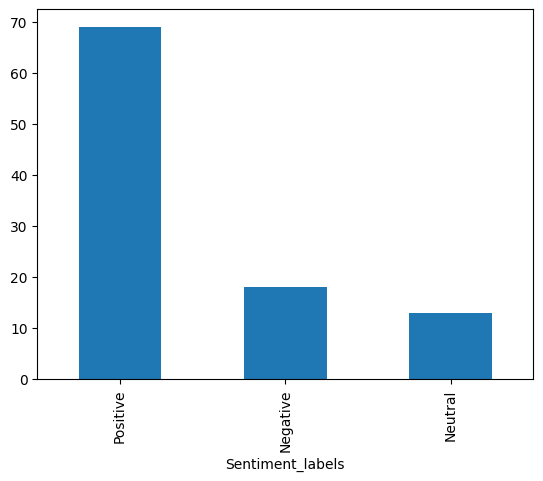

In [38]:
data['Sentiment_labels'].value_counts().plot.bar()